# Maze RL — Обучение агента решению лабиринтов

**PPO (Proximal Policy Optimization) + CNN Actor-Critic**

Лабиринт 21×21, вход (1,0), выход (19,20), 4 действия (вниз/вправо/вверх/влево).

Три стадии:
1. Исследование (посещение новых клеток)
2. Поиск выхода (штраф за длину пути)
3. Кратчайший путь (штраф за отклонение от оптимального пути)

## 0. Установка зависимостей

In [1]:
# Раскомментируйте нужное:

# Для Google Colab (GPU рекомендуется: Runtime → Change runtime type → T4 GPU):
# !pip install torch numpy matplotlib

# Для Kaggle — всё уже установлено

# Для локального Jupyter:
!pip install torch numpy matplotlib

   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.2 MB ? eta -:--:--
   --- ------------------------------------ 0.5/6.2 MB 1.7 MB/s eta 0:00:04
   --- ------------------------------------ 0.5/6.2 MB 1.7 MB/s eta 0:00:04
   -------- ------------------------------- 1.3/6.2 MB 1.3 MB/s eta 0:00:04
   -------- ------------------------------- 1.3/6.2 MB 1.3 MB/s eta 0:00:04
   ---------- ----------------------------- 1.6/6.2 MB 1.2 MB/s eta 0:00:04
   ------------- -------------------------- 2.1/6.2 MB 1.3 MB/s eta 0:00:04
   ---------------- ----------------------- 2.6/6.2 MB 1.5 MB/s eta 0:00:03
   ------------------ --------------------- 2.9/6.2 MB 1.5 MB/s eta 0:00:03
   -------------------- ------------------- 3.1/6.2 MB 1.5 MB/s eta 0:00:03
   ----------------------- -------------

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
from collections import deque
import hashlib
import random
import time
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import clear_output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cpu


## 1. Генератор лабиринтов

In [4]:
# ==================== Disjoint Set ====================

class DisjointSet:
    def __init__(self, items):
        self.items = items
        self.parent = list(range(len(items)))
        self.size = [1] * len(items)

    def find(self, x):
        item = x
        while item != self.parent[item]:
            item = self.parent[item]
        root = item
        while x != root:
            parent = self.parent[x]
            self.parent[x] = root
            x = parent
        return root

    def union(self, a, b):
        root_a, root_b = self.find(a), self.find(b)
        if root_a != root_b:
            if self.size[root_a] < self.size[root_b]:
                self.size[root_b] += self.size[root_a]
                self.parent[root_a] = root_b
            else:
                self.size[root_a] += self.size[root_b]
                self.parent[root_b] = root_a
        return root_a


# ==================== Kruskal Maze ====================

class KruskalRectangular:
    def __init__(self, n):
        self.n = n
        self.total_cells = n ** 2
        self.TOP, self.RIGHT, self.BOTTOM, self.LEFT = 0, 1, 2, 3

    def create_graph(self):
        edges = []
        for row in range(self.n):
            for col in range(self.n):
                node = self.n * row + col
                if col < self.n - 1:
                    edges.append((node, node + 1))
                if row < self.n - 1:
                    edges.append((node, node + self.n))
        return edges

    def kruskal_spanning_tree(self):
        edges_of_graph = self.create_graph()
        spanning_tree = {cell: [0, 0, 0, 0] for cell in range(self.total_cells)}
        edges = []
        cells = list(range(self.total_cells))
        disjoint = DisjointSet(cells)
        random.shuffle(edges_of_graph)
        for edge in edges_of_graph:
            cell1, cell2 = edge
            if disjoint.find(cell1) != disjoint.find(cell2):
                disjoint.union(cell1, cell2)
                d1 = self.get_neighbour_dir(cell1, cell2)
                d2 = self.get_neighbour_dir(cell2, cell1)
                spanning_tree[cell1][d1] = 1
                spanning_tree[cell2][d2] = 1
                edges.append(edge)
        return spanning_tree, edges

    def get_neighbour_dir(self, cell1, cell2):
        if cell1 == cell2 + self.n: return self.TOP
        elif cell1 == cell2 - 1:   return self.RIGHT
        elif cell1 == cell2 + 1:   return self.LEFT
        elif cell1 == cell2 - self.n: return self.BOTTOM


# ==================== Maze Generator ====================

def make_maze(n):
    algo = KruskalRectangular(n)
    spanning_tree, edges = algo.kruskal_spanning_tree()
    size = 2 * n + 1
    result = np.zeros((size, size), dtype=np.int32)
    for i in range(n):
        for j in range(n):
            y, x, node = 2*i+1, 2*j+1, i*n+j
            result[y, x] = 1
            result[y, x+1] = (j+1 < n and spanning_tree[node][algo.RIGHT]) or result[y, x+1]
            result[y+1, x] = (i+1 < n and spanning_tree[node][algo.BOTTOM]) or result[y+1, x]
    result[1, 0] = result[-2, -1] = 1
    return result, edges


def generate_mazes(n, maze_size):
    result, hashes = [], {'PLACEHOLDER'}
    for i in range(n):
        if (i+1) % 200 == 0:
            print(f'  {i+1}/{n} лабиринтов сгенерировано')
        key = 'PLACEHOLDER'
        while key in hashes:
            maze, edges = make_maze(maze_size)
            key = hashlib.sha256(str(edges).encode()).hexdigest()
        hashes.add(key)
        result.append(maze)
    return np.stack(result)

## 2. Среда (Vectorized NumPy Environment)

In [5]:
def bfs_shortest_path(maze):
    """BFS для нахождения кратчайшего пути. Возвращает бинарную маску."""
    H, W = maze.shape
    start, end = (1, 0), (19, 20)
    prev = {start: None}
    queue = deque([start])
    while queue:
        r, c = queue.popleft()
        if (r, c) == end:
            break
        for dr, dc in [(1,0),(0,1),(-1,0),(0,-1)]:
            nr, nc = r+dr, c+dc
            if 0 <= nr < H and 0 <= nc < W and maze[nr,nc] == 1 and (nr,nc) not in prev:
                prev[(nr,nc)] = (r,c)
                queue.append((nr,nc))
    mask = np.zeros((H,W), dtype=np.float32)
    cell = end
    if cell not in prev:
        return mask
    while cell is not None:
        mask[cell[0], cell[1]] = 1.0
        cell = prev[cell]
    return mask


def compute_all_shortest_paths(mazes):
    masks = np.zeros_like(mazes, dtype=np.float32)
    for i in range(len(mazes)):
        masks[i] = bfs_shortest_path(mazes[i])
    return masks


class VecMazeEnv:
    """
    Векторизованная среда лабиринта (только numpy-операции).
    
    Наблюдение: (n_envs, 3, 21, 21) float32
        Канал 0: лабиринт (0=стена, 1=проход)
        Канал 1: позиция агента (one-hot)
        Канал 2: позиция выхода (one-hot)
    
    Действия: 0=вниз, 1=вправо, 2=вверх, 3=влево
    """
    GRID_SIZE = 21
    ENTRY = np.array([1, 0], dtype=np.int32)
    EXIT  = np.array([19, 20], dtype=np.int32)
    DR = np.array([1, 0, -1, 0], dtype=np.int32)   # row deltas
    DC = np.array([0, 1,  0, -1], dtype=np.int32)   # col deltas

    def __init__(self, maze_pool, n_envs, max_steps=200, stage=1, shortest_path_masks=None):
        self.maze_pool = maze_pool.astype(np.float32)
        self.n_envs = n_envs
        self.max_steps = max_steps
        self.stage = stage
        self.sp_masks_pool = shortest_path_masks

        self.maze_indices = np.zeros(n_envs, dtype=np.int64)
        self.mazes = np.zeros((n_envs, self.GRID_SIZE, self.GRID_SIZE), dtype=np.float32)
        self.sp_masks = np.zeros((n_envs, self.GRID_SIZE, self.GRID_SIZE), dtype=np.float32)
        self.pos_r = np.zeros(n_envs, dtype=np.int32)
        self.pos_c = np.zeros(n_envs, dtype=np.int32)
        self.steps = np.zeros(n_envs, dtype=np.int32)
        self.visited = np.zeros((n_envs, self.GRID_SIZE, self.GRID_SIZE), dtype=np.float32)
        self.done = np.zeros(n_envs, dtype=bool)

    def reset(self, indices=None):
        if indices is None:
            indices = np.arange(self.n_envs)
        n = len(indices)
        mi = np.random.randint(0, len(self.maze_pool), size=n)
        self.maze_indices[indices] = mi
        self.mazes[indices] = self.maze_pool[mi]
        if self.sp_masks_pool is not None:
            self.sp_masks[indices] = self.sp_masks_pool[mi]
        self.pos_r[indices] = self.ENTRY[0]
        self.pos_c[indices] = self.ENTRY[1]
        self.steps[indices] = 0
        self.visited[indices] = 0.0
        self.visited[indices, self.ENTRY[0], self.ENTRY[1]] = 1.0
        self.done[indices] = False
        return self._get_obs()

    def step(self, actions):
        """Шаг во всех средах одновременно (numpy-векторизация)."""
        env_idx = np.arange(self.n_envs)
        alive = ~self.done

        # Новые позиции
        new_r = self.pos_r + self.DR[actions]
        new_c = self.pos_c + self.DC[actions]
        new_r = np.clip(new_r, 0, self.GRID_SIZE - 1)
        new_c = np.clip(new_c, 0, self.GRID_SIZE - 1)

        # Проверка проходимости
        walkable = self.mazes[env_idx, new_r, new_c] > 0.5
        valid_move = alive & walkable

        # Обновление позиций
        self.pos_r = np.where(valid_move, new_r, self.pos_r)
        self.pos_c = np.where(valid_move, new_c, self.pos_c)

        # Отслеживание посещённых клеток
        was_visited = self.visited[env_idx, self.pos_r, self.pos_c].copy()
        self.visited[env_idx, self.pos_r, self.pos_c] = 1.0
        is_new_cell = (was_visited < 0.5) & alive

        self.steps += alive.astype(np.int32)

        reached_exit = (self.pos_r == self.EXIT[0]) & (self.pos_c == self.EXIT[1]) & alive
        timeout = (self.steps >= self.max_steps) & alive & ~reached_exit

        rewards = self._compute_rewards(alive, is_new_cell, reached_exit, timeout, valid_move)
        self.done = self.done | reached_exit | timeout

        infos = {'reached_exit': reached_exit, 'timeout': timeout, 'steps': self.steps.copy()}
        return self._get_obs(), rewards, self.done.copy(), infos

    def _compute_rewards(self, alive, is_new_cell, reached_exit, timeout, valid_move):
        rewards = np.zeros(self.n_envs, dtype=np.float32)
        env_idx = np.arange(self.n_envs)

        if self.stage == 1:
            rewards += is_new_cell.astype(np.float32) * 1.0
            rewards += reached_exit.astype(np.float32) * 10.0

        elif self.stage == 2:
            rewards += reached_exit.astype(np.float32) * 50.0
            rewards -= alive.astype(np.float32) * 0.1
            rewards += is_new_cell.astype(np.float32) * 0.5
            rewards -= timeout.astype(np.float32) * 5.0

        elif self.stage == 3:
            on_sp = self.sp_masks[env_idx, self.pos_r, self.pos_c]
            off_sp = (1.0 - on_sp) * alive.astype(np.float32)
            rewards += reached_exit.astype(np.float32) * 50.0
            rewards -= alive.astype(np.float32) * 0.1
            rewards -= off_sp * 1.0
            rewards += on_sp * alive.astype(np.float32) * 0.2
            rewards -= timeout.astype(np.float32) * 5.0

        return rewards

    def _get_obs(self):
        obs = np.zeros((self.n_envs, 3, self.GRID_SIZE, self.GRID_SIZE), dtype=np.float32)
        obs[:, 0] = self.mazes
        env_idx = np.arange(self.n_envs)
        obs[env_idx, 1, self.pos_r, self.pos_c] = 1.0
        obs[:, 2, self.EXIT[0], self.EXIT[1]] = 1.0
        return obs

    def auto_reset_done(self):
        done_idx = np.where(self.done)[0]
        if len(done_idx) > 0:
            self.reset(done_idx)
        return self._get_obs()

    def get_shortest_path_lengths(self):
        if self.sp_masks_pool is None:
            return np.zeros(self.n_envs)
        return self.sp_masks[np.arange(self.n_envs)].sum(axis=(1,2))

## 3. CNN Actor-Critic модель

In [6]:
class MazeCNN(nn.Module):
    """
    Свёрточная Actor-Critic сеть.
    Вход: (batch, 3, 21, 21)
    Выход: policy_logits (batch, 4), value (batch,)
    """
    def __init__(self, in_channels=3, n_actions=4):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),   # 21→11
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=2, padding=1),   # 11→6
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # 6→3
            nn.ReLU(),
        )
        self.flat_dim = 128 * 3 * 3
        self.shared_fc = nn.Sequential(nn.Linear(self.flat_dim, 256), nn.ReLU())
        self.policy_head = nn.Linear(256, n_actions)
        self.value_head = nn.Linear(256, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=0.01 if m is self.policy_head else 1.0)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        features = self.conv(x).view(x.size(0), -1)
        features = self.shared_fc(features)
        return self.policy_head(features), self.value_head(features).squeeze(-1)

    def get_action_and_value(self, obs, action=None):
        logits, value = self.forward(obs)
        dist = Categorical(logits=logits)
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), value

    def get_value(self, obs):
        _, value = self.forward(obs)
        return value


model = MazeCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Модель загружена.  Параметров: {total_params:,}')

Модель загружена.  Параметров: 426,629


## 4. PPO (Proximal Policy Optimization)

In [7]:
class RolloutBuffer:
    """Хранилище данных роллаута для PPO."""
    def __init__(self, n_steps, n_envs, obs_shape, dev):
        self.n_steps, self.n_envs, self.device = n_steps, n_envs, dev
        self.obs       = np.zeros((n_steps, n_envs, *obs_shape), dtype=np.float32)
        self.actions    = np.zeros((n_steps, n_envs), dtype=np.int64)
        self.log_probs  = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.rewards    = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.dones      = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.values     = np.zeros((n_steps, n_envs), dtype=np.float32)
        self.ptr = 0

    def store(self, obs, actions, log_probs, rewards, dones, values):
        self.obs[self.ptr] = obs
        self.actions[self.ptr] = actions
        self.log_probs[self.ptr] = log_probs
        self.rewards[self.ptr] = rewards
        self.dones[self.ptr] = dones
        self.values[self.ptr] = values
        self.ptr += 1

    def reset(self):
        self.ptr = 0

    def compute_gae(self, last_values, last_dones, gamma=0.99, lam=0.95):
        advantages = np.zeros_like(self.rewards)
        last_gae = 0.0
        for t in reversed(range(self.n_steps)):
            next_val = last_values if t == self.n_steps - 1 else self.values[t+1]
            next_done = last_dones if t == self.n_steps - 1 else self.dones[t+1]
            delta = self.rewards[t] + gamma * next_val * (1 - next_done) - self.values[t]
            last_gae = delta + gamma * lam * (1 - next_done) * last_gae
            advantages[t] = last_gae
        returns = advantages + self.values
        return advantages, returns

    def get_batches(self, advantages, returns, batch_size):
        total = self.n_steps * self.n_envs
        indices = np.arange(total)
        np.random.shuffle(indices)
        flat = lambda x: x.reshape(total, *x.shape[2:]) if x.ndim > 2 else x.reshape(total)
        obs_f, act_f = flat(self.obs), flat(self.actions)
        lp_f, val_f = flat(self.log_probs), flat(self.values)
        adv_f, ret_f = flat(advantages), flat(returns)
        for s in range(0, total, batch_size):
            idx = indices[s:s+batch_size]
            yield {
                'obs': torch.tensor(obs_f[idx], device=self.device),
                'actions': torch.tensor(act_f[idx], device=self.device),
                'old_log_probs': torch.tensor(lp_f[idx], device=self.device),
                'old_values': torch.tensor(val_f[idx], device=self.device),
                'advantages': torch.tensor(adv_f[idx], device=self.device),
                'returns': torch.tensor(ret_f[idx], device=self.device),
            }


class PPO:
    """
    Proximal Policy Optimization.
    
    L^CLIP(θ) = E[min(r(θ)·A, clip(r(θ), 1±ε)·A)]
    где r(θ) = π_θ(a|s) / π_old(a|s)
    """
    def __init__(self, model, dev, lr=3e-4, gamma=0.99, gae_lambda=0.95,
                 clip_eps=0.2, entropy_coef=0.01, value_coef=0.5,
                 max_grad_norm=0.5, n_epochs=4, batch_size=256):
        self.model = model
        self.device = dev
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_eps = clip_eps
        self.entropy_coef = entropy_coef
        self.value_coef = value_coef
        self.max_grad_norm = max_grad_norm
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.optimizer = optim.Adam(model.parameters(), lr=lr, eps=1e-5)

    def update(self, buffer, last_values, last_dones):
        advantages, returns = buffer.compute_gae(last_values, last_dones,
                                                  self.gamma, self.gae_lambda)
        adv_norm = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        stats = {'policy_loss': 0, 'value_loss': 0, 'entropy': 0, 'clip_frac': 0}
        n_updates = 0

        for _ in range(self.n_epochs):
            for batch in buffer.get_batches(adv_norm, returns, self.batch_size):
                _, new_lp, ent, new_val = self.model.get_action_and_value(
                    batch['obs'], batch['actions'])

                ratio = torch.exp(new_lp - batch['old_log_probs'])
                surr1 = ratio * batch['advantages']
                surr2 = torch.clamp(ratio, 1-self.clip_eps, 1+self.clip_eps) * batch['advantages']
                policy_loss = -torch.min(surr1, surr2).mean()

                val_clipped = batch['old_values'] + torch.clamp(
                    new_val - batch['old_values'], -self.clip_eps, self.clip_eps)
                value_loss = 0.5 * torch.max(
                    (new_val - batch['returns'])**2,
                    (val_clipped - batch['returns'])**2
                ).mean()

                loss = policy_loss + self.value_coef * value_loss - self.entropy_coef * ent.mean()

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)
                self.optimizer.step()

                with torch.no_grad():
                    stats['policy_loss'] += policy_loss.item()
                    stats['value_loss']  += value_loss.item()
                    stats['entropy']     += ent.mean().item()
                    stats['clip_frac']   += ((ratio-1).abs() > self.clip_eps).float().mean().item()
                    n_updates += 1

        return {k: v/n_updates for k, v in stats.items()}

    def collect_rollout(self, env, buffer, obs):
        buffer.reset()
        episode_infos = []
        for _ in range(buffer.n_steps):
            with torch.no_grad():
                obs_t = torch.tensor(obs, device=self.device)
                actions, log_probs, _, values = self.model.get_action_and_value(obs_t)
                act_np = actions.cpu().numpy()
                lp_np  = log_probs.cpu().numpy()
                val_np = values.cpu().numpy()

            next_obs, rewards, dones, infos = env.step(act_np)
            buffer.store(obs, act_np, lp_np, rewards, dones.astype(np.float32), val_np)

            for i in range(env.n_envs):
                if infos['reached_exit'][i] or infos['timeout'][i]:
                    episode_infos.append({
                        'reached_exit': bool(infos['reached_exit'][i]),
                        'steps': int(infos['steps'][i]),
                    })
            obs = env.auto_reset_done()
        return obs, episode_infos

## 5. Генерация данных

In [8]:
N_TRAIN_MAZES = 1000   # Количество лабиринтов для обучения
N_EVAL_MAZES  = 100    # Количество лабиринтов для оценки
MAZE_SIZE     = 10     # Параметр генератора (результат 21×21)

print(f'Генерация {N_TRAIN_MAZES} обучающих лабиринтов...')
train_mazes = generate_mazes(N_TRAIN_MAZES, MAZE_SIZE)
print(f'Генерация {N_EVAL_MAZES} тестовых лабиринтов...')
eval_mazes = generate_mazes(N_EVAL_MAZES, MAZE_SIZE)

print(f'\nВычисление кратчайших путей...')
sp_masks_train = compute_all_shortest_paths(train_mazes)
sp_masks_eval  = compute_all_shortest_paths(eval_mazes)

avg_sp = sp_masks_train.sum(axis=(1,2)).mean()
print(f'Средняя длина кратчайшего пути: {avg_sp:.1f} клеток')
print(f'Форма лабиринта: {train_mazes[0].shape}')

Генерация 1000 обучающих лабиринтов...
  200/1000 лабиринтов сгенерировано
  400/1000 лабиринтов сгенерировано
  600/1000 лабиринтов сгенерировано
  800/1000 лабиринтов сгенерировано
  1000/1000 лабиринтов сгенерировано
Генерация 100 тестовых лабиринтов...

Вычисление кратчайших путей...
Средняя длина кратчайшего пути: 50.5 клеток
Форма лабиринта: (21, 21)


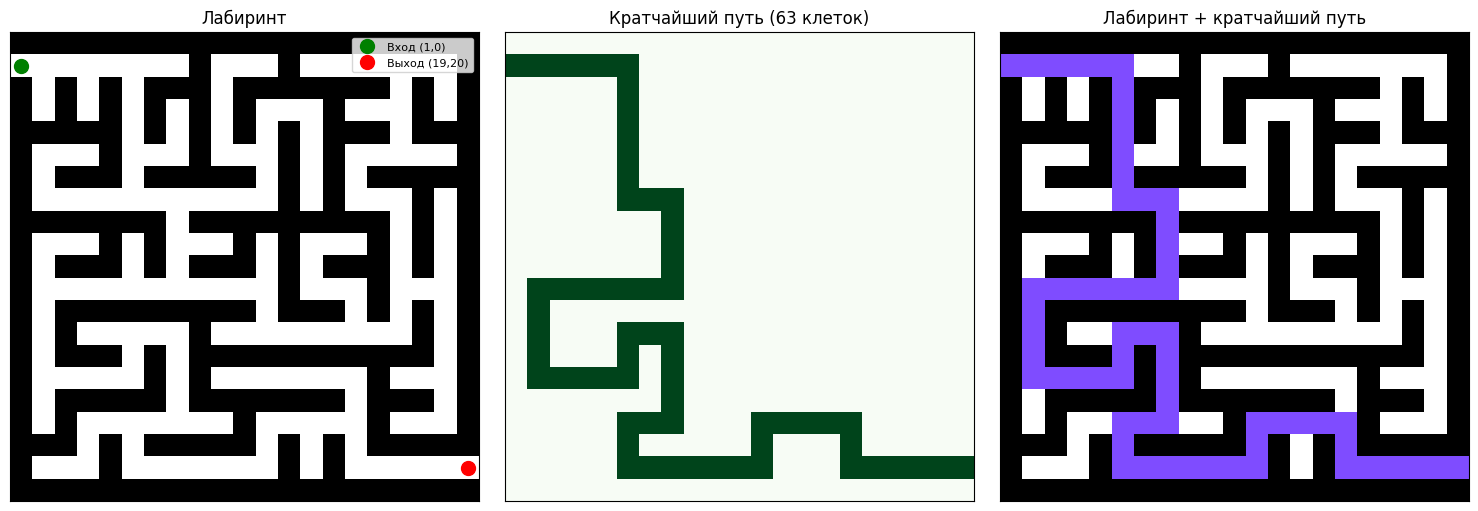

In [9]:
# Визуализация примера лабиринта
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

idx = 0
maze = train_mazes[idx]
sp = sp_masks_train[idx]

axes[0].imshow(maze, cmap='binary_r')
axes[0].set_title('Лабиринт')
axes[0].plot(0, 1, 'go', markersize=10, label='Вход (1,0)')
axes[0].plot(20, 19, 'ro', markersize=10, label='Выход (19,20)')
axes[0].legend(fontsize=8)

axes[1].imshow(sp, cmap='Greens')
axes[1].set_title(f'Кратчайший путь ({int(sp.sum())} клеток)')

# Лабиринт + путь наложение
combined = np.stack([maze * (1 - sp * 0.5), maze * (1 - sp * 0.7), maze], axis=-1)
axes[2].imshow(combined)
axes[2].set_title('Лабиринт + кратчайший путь')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## 6. Вспомогательные функции

In [11]:
def evaluate_model(model, mazes, sp_masks, stage, n_eval=100, max_steps=200):
    """Оценка модели на тестовых лабиринтах (жадная политика)."""
    env = VecMazeEnv(mazes, n_envs=n_eval, max_steps=max_steps,
                     stage=stage, shortest_path_masks=sp_masks)
    obs = env.reset()
    reached = np.zeros(n_eval, dtype=bool)
    total_steps = np.zeros(n_eval, dtype=np.int32)
    done_flags = np.zeros(n_eval, dtype=bool)

    for _ in range(max_steps):
        with torch.no_grad():
            logits, _ = model(torch.tensor(obs, device=device))
            actions = logits.argmax(dim=-1).cpu().numpy()
        obs, _, dones, infos = env.step(actions)
        for i in range(n_eval):
            if (infos['reached_exit'][i] or infos['timeout'][i]) and not done_flags[i]:
                reached[i] = infos['reached_exit'][i]
                total_steps[i] = infos['steps'][i]
                done_flags[i] = True
        if done_flags.all():
            break

    success_rate = reached.mean()
    avg_steps = total_steps[reached].mean() if reached.any() else max_steps
    return {'success_rate': float(success_rate), 'avg_steps': float(avg_steps)}


def plot_training_curves(history, stage_name):
    """Визуализация кривых обучения."""
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    
    axes[0].plot(history['exit_rate'], alpha=0.3, color='blue')
    if len(history['exit_rate']) > 10:
        window = min(20, len(history['exit_rate'])//3)
        smoothed = np.convolve(history['exit_rate'], np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(history['exit_rate'])), smoothed, color='blue', linewidth=2)
    axes[0].set_title('Exit Rate')
    axes[0].set_ylim(-0.05, 1.05)

    axes[1].plot(history['avg_steps'], alpha=0.5, color='orange')
    axes[1].set_title('Avg Steps')

    axes[2].plot(history['policy_loss'], alpha=0.5, color='red')
    axes[2].set_title('Policy Loss')

    axes[3].plot(history['entropy'], alpha=0.5, color='green')
    axes[3].set_title('Entropy')

    fig.suptitle(f'Обучение: {stage_name}', fontsize=14)
    for ax in axes:
        ax.set_xlabel('Итерация')
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Обучение

### Гиперпараметры

| Параметр | Значение | Описание |
|----------|---------|----------|
| `N_ENVS` | 64 | Количество параллельных сред |
| `N_STEPS` | 256 | Длина роллаута за итерацию |
| `N_EPOCHS` | 4 | Эпох PPO на один роллаут |
| `BATCH_SIZE` | 256 | Размер мини-батча |
| `γ` | 0.99 | Дисконт |
| `λ` (GAE) | 0.95 | Коэффициент GAE |
| `ε` (clip) | 0.2 | Ограничение PPO |

In [12]:
# ======================== ГИПЕРПАРАМЕТРЫ ========================

N_ENVS     = 64        # Параллельных сред
N_STEPS    = 256       # Шагов в роллауте
MAX_STEPS  = 200       # Максимум шагов в эпизоде
GAMMA      = 0.99
GAE_LAMBDA = 0.95
CLIP_EPS   = 0.2
VALUE_COEF = 0.5
N_EPOCHS   = 4
BATCH_SIZE = 256

# Настройки по стадиям
STAGE_CONFIG = {
    1: {'name': 'Исследование',    'n_iter': 300, 'lr': 3e-4, 'ent_coef': 0.05},
    2: {'name': 'Поиск выхода',    'n_iter': 500, 'lr': 2e-4, 'ent_coef': 0.02},
    3: {'name': 'Кратчайший путь', 'n_iter': 500, 'lr': 1e-4, 'ent_coef': 0.01},
}

In [13]:
def train_stage(stage, model, config):
    """Обучение одной стадии."""
    cfg = config
    n_iter = cfg['n_iter']
    stage_name = cfg['name']
    
    print(f"\n{'='*60}")
    print(f"  СТАДИЯ {stage}: {stage_name}")
    print(f"  Итераций: {n_iter}, LR: {cfg['lr']}, Entropy: {cfg['ent_coef']}")
    print(f"{'='*60}")

    env = VecMazeEnv(train_mazes, n_envs=N_ENVS, max_steps=MAX_STEPS,
                     stage=stage, shortest_path_masks=sp_masks_train)

    ppo = PPO(model, device, lr=cfg['lr'], gamma=GAMMA, gae_lambda=GAE_LAMBDA,
              clip_eps=CLIP_EPS, entropy_coef=cfg['ent_coef'], value_coef=VALUE_COEF,
              n_epochs=N_EPOCHS, batch_size=BATCH_SIZE)

    buffer = RolloutBuffer(N_STEPS, N_ENVS, (3, 21, 21), device)
    obs = env.reset()

    history = {'exit_rate': [], 'avg_steps': [], 'policy_loss': [], 'entropy': []}
    log_interval = max(1, n_iter // 20)
    eval_interval = max(1, n_iter // 5)
    start_time = time.time()

    for it in range(1, n_iter + 1):
        obs, ep_infos = ppo.collect_rollout(env, buffer, obs)

        with torch.no_grad():
            last_vals = model.get_value(torch.tensor(obs, device=device)).cpu().numpy()

        metrics = ppo.update(buffer, last_vals, env.done.astype(np.float32))

        # Статистика эпизодов
        if ep_infos:
            exits = sum(1 for e in ep_infos if e['reached_exit'])
            exit_rate = exits / len(ep_infos)
            avg_steps = np.mean([e['steps'] for e in ep_infos])
        else:
            exit_rate, avg_steps = 0, MAX_STEPS

        history['exit_rate'].append(exit_rate)
        history['avg_steps'].append(avg_steps)
        history['policy_loss'].append(metrics['policy_loss'])
        history['entropy'].append(metrics['entropy'])

        if it % log_interval == 0:
            elapsed = time.time() - start_time
            fps = (it * N_STEPS * N_ENVS) / elapsed
            print(f"  Iter {it:4d}/{n_iter} | "
                  f"Exit: {exit_rate:.0%} | "
                  f"Steps: {avg_steps:.0f} | "
                  f"PL: {metrics['policy_loss']:.4f} | "
                  f"Ent: {metrics['entropy']:.3f} | "
                  f"FPS: {fps:.0f}")

        if it % eval_interval == 0:
            ev = evaluate_model(model, eval_mazes, sp_masks_eval, stage)
            print(f"  >>> EVAL: Success={ev['success_rate']:.0%}, Avg steps={ev['avg_steps']:.1f}")

    # Финальная оценка
    final = evaluate_model(model, eval_mazes, sp_masks_eval, stage)
    print(f"\n  Финал стадии {stage}: Success={final['success_rate']:.0%}, Steps={final['avg_steps']:.1f}")

    plot_training_curves(history, f'Стадия {stage}: {stage_name}')
    return model, history

### Стадия 1: Исследование
Агент учится перемещаться по лабиринту и посещать новые клетки.


  СТАДИЯ 1: Исследование
  Итераций: 300, LR: 0.0003, Entropy: 0.05
  Iter   15/300 | Exit: 0% | Steps: 200 | PL: -0.0109 | Ent: 1.258 | FPS: 1415
  Iter   30/300 | Exit: 0% | Steps: 200 | PL: -0.0123 | Ent: 1.231 | FPS: 1451
  Iter   45/300 | Exit: 13% | Steps: 191 | PL: -0.0130 | Ent: 1.181 | FPS: 1469
  Iter   60/300 | Exit: 10% | Steps: 194 | PL: -0.0107 | Ent: 1.166 | FPS: 1470
  >>> EVAL: Success=0%, Avg steps=200.0
  Iter   75/300 | Exit: 2% | Steps: 198 | PL: -0.0119 | Ent: 1.144 | FPS: 1474
  Iter   90/300 | Exit: 9% | Steps: 193 | PL: -0.0118 | Ent: 1.139 | FPS: 1479
  Iter  105/300 | Exit: 0% | Steps: 200 | PL: -0.0125 | Ent: 1.156 | FPS: 1482
  Iter  120/300 | Exit: 6% | Steps: 195 | PL: -0.0118 | Ent: 1.141 | FPS: 1485
  >>> EVAL: Success=0%, Avg steps=200.0
  Iter  135/300 | Exit: 3% | Steps: 199 | PL: -0.0116 | Ent: 1.120 | FPS: 1486
  Iter  150/300 | Exit: 0% | Steps: 200 | PL: -0.0116 | Ent: 1.127 | FPS: 1488
  Iter  165/300 | Exit: 6% | Steps: 197 | PL: -0.0126 | Ent

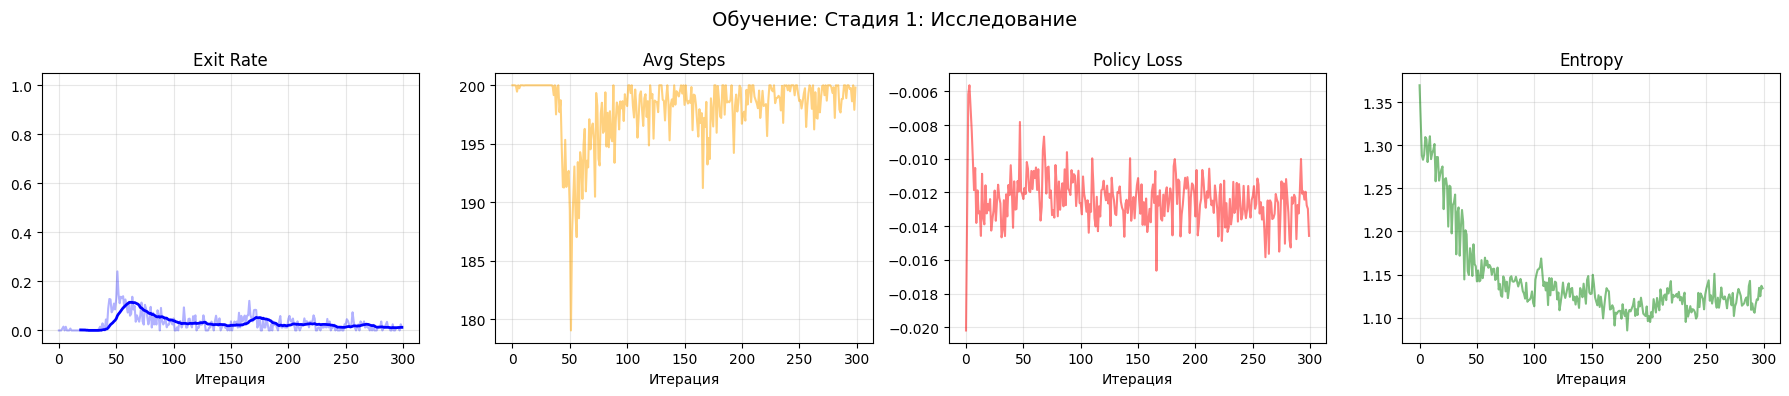

In [14]:
model = MazeCNN().to(device)
model, hist1 = train_stage(1, model, STAGE_CONFIG[1])

### Стадия 2: Поиск выхода
Агент учится находить выход, минимизируя длину пути. Веса наследуются от стадии 1.


  СТАДИЯ 2: Поиск выхода
  Итераций: 500, LR: 0.0002, Entropy: 0.02
  Iter   25/500 | Exit: 0% | Steps: 200 | PL: -0.0120 | Ent: 0.996 | FPS: 1505
  Iter   50/500 | Exit: 0% | Steps: 200 | PL: -0.0121 | Ent: 0.942 | FPS: 1506
  Iter   75/500 | Exit: 0% | Steps: 200 | PL: -0.0141 | Ent: 0.918 | FPS: 1506
  Iter  100/500 | Exit: 10% | Steps: 189 | PL: -0.0108 | Ent: 0.897 | FPS: 1507
  >>> EVAL: Success=0%, Avg steps=200.0
  Iter  125/500 | Exit: 35% | Steps: 149 | PL: -0.0118 | Ent: 0.741 | FPS: 1506
  Iter  150/500 | Exit: 33% | Steps: 152 | PL: -0.0112 | Ent: 0.791 | FPS: 1505
  Iter  175/500 | Exit: 66% | Steps: 106 | PL: -0.0104 | Ent: 0.716 | FPS: 1505
  Iter  200/500 | Exit: 77% | Steps: 90 | PL: -0.0064 | Ent: 0.675 | FPS: 1505
  >>> EVAL: Success=29%, Avg steps=43.9
  Iter  225/500 | Exit: 84% | Steps: 79 | PL: -0.0043 | Ent: 0.506 | FPS: 1505
  Iter  250/500 | Exit: 79% | Steps: 84 | PL: -0.0073 | Ent: 0.577 | FPS: 1505
  Iter  275/500 | Exit: 81% | Steps: 79 | PL: -0.0078 | E

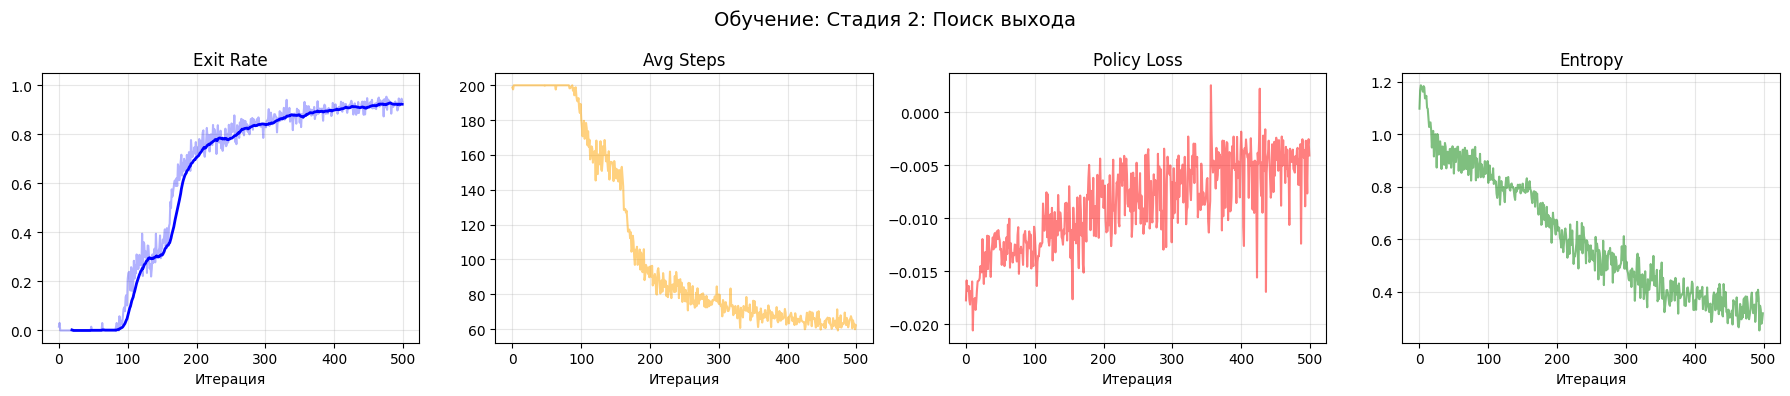

In [15]:
model, hist2 = train_stage(2, model, STAGE_CONFIG[2])

### Стадия 3: Кратчайший путь
Агент учится следовать строго по кратчайшему пути (BFS). Штраф за отклонение от оптимального маршрута.


  СТАДИЯ 3: Кратчайший путь
  Итераций: 500, LR: 0.0001, Entropy: 0.01
  Iter   25/500 | Exit: 97% | Steps: 56 | PL: -0.0094 | Ent: 0.263 | FPS: 1501
  Iter   50/500 | Exit: 75% | Steps: 99 | PL: -0.0037 | Ent: 0.427 | FPS: 1502
  Iter   75/500 | Exit: 0% | Steps: 200 | PL: -0.0060 | Ent: 0.813 | FPS: 1502
  Iter  100/500 | Exit: 1% | Steps: 199 | PL: -0.0093 | Ent: 1.111 | FPS: 1501
  >>> EVAL: Success=0%, Avg steps=200.0
  Iter  125/500 | Exit: 0% | Steps: 200 | PL: -0.0087 | Ent: 1.172 | FPS: 1501
  Iter  150/500 | Exit: 0% | Steps: 200 | PL: -0.0088 | Ent: 1.169 | FPS: 1501
  Iter  175/500 | Exit: 0% | Steps: 200 | PL: -0.0085 | Ent: 1.188 | FPS: 1501
  Iter  200/500 | Exit: 0% | Steps: 200 | PL: -0.0101 | Ent: 1.178 | FPS: 1502
  >>> EVAL: Success=0%, Avg steps=200.0
  Iter  225/500 | Exit: 0% | Steps: 200 | PL: -0.0099 | Ent: 1.165 | FPS: 1501
  Iter  250/500 | Exit: 0% | Steps: 200 | PL: -0.0083 | Ent: 1.192 | FPS: 1502
  Iter  275/500 | Exit: 0% | Steps: 200 | PL: -0.0110 | En

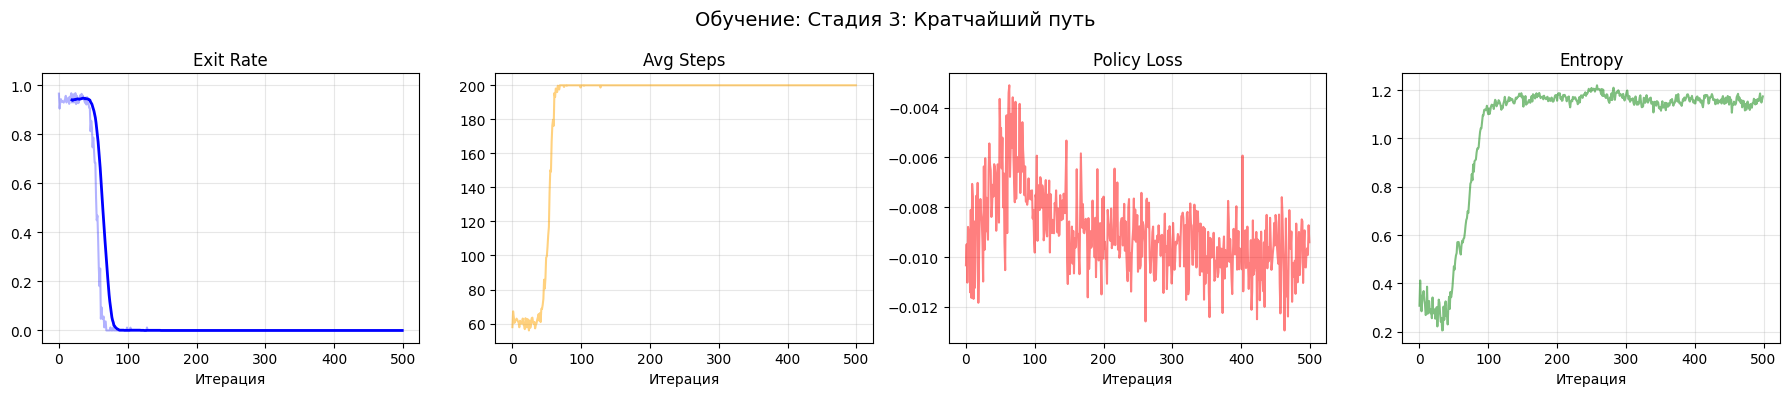

In [16]:
model, hist3 = train_stage(3, model, STAGE_CONFIG[3])

## 8. Итоговая оценка

In [17]:
print('\n' + '='*60)
print('  ИТОГОВАЯ ОЦЕНКА НА ТЕСТОВЫХ ЛАБИРИНТАХ')
print('='*60)
for stage in [1, 2, 3]:
    ev = evaluate_model(model, eval_mazes, sp_masks_eval, stage, n_eval=100)
    print(f"  Стадия {stage} | Success: {ev['success_rate']:.0%} | Avg steps: {ev['avg_steps']:.1f}")


  ИТОГОВАЯ ОЦЕНКА НА ТЕСТОВЫХ ЛАБИРИНТАХ
  Стадия 1 | Success: 0% | Avg steps: 200.0
  Стадия 2 | Success: 0% | Avg steps: 200.0
  Стадия 3 | Success: 0% | Avg steps: 200.0


## 9. Визуализация решения лабиринта


Лабиринт #27:


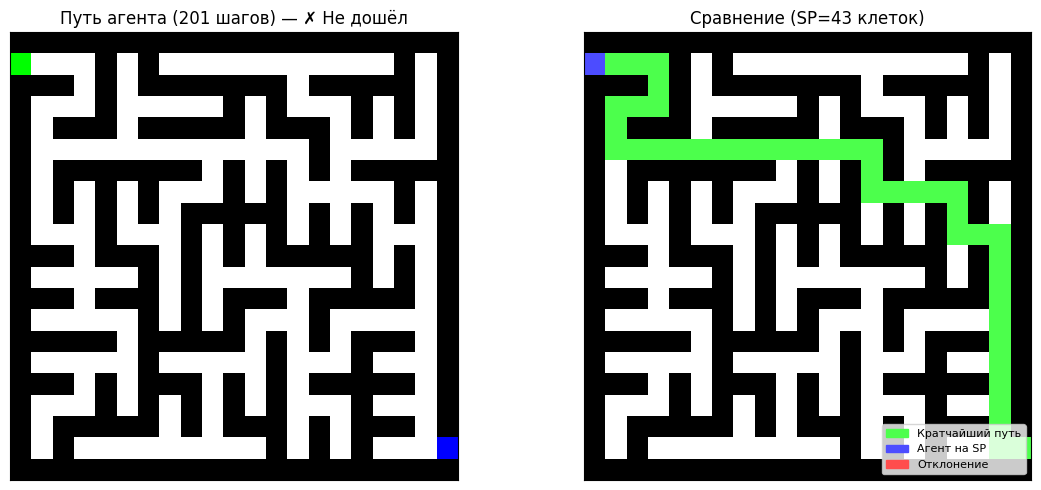


Лабиринт #82:


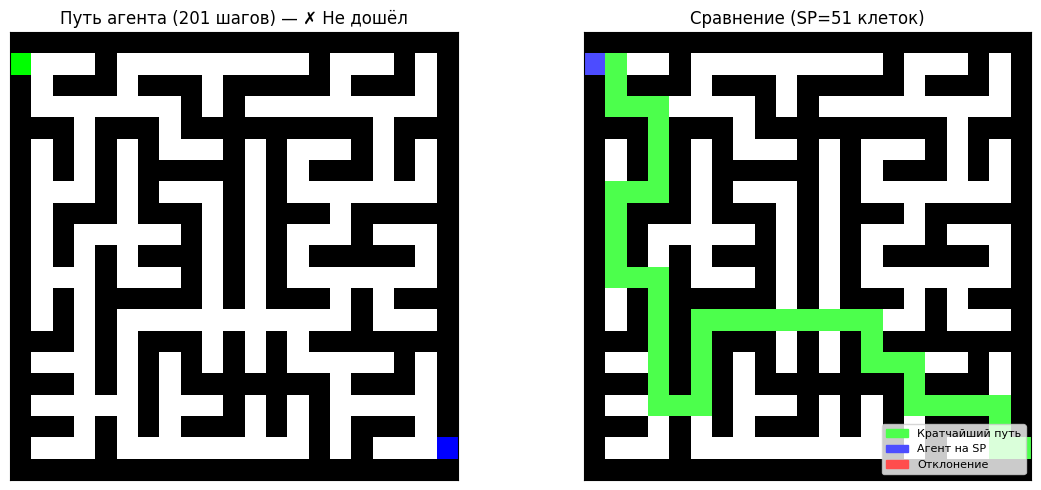


Лабиринт #39:


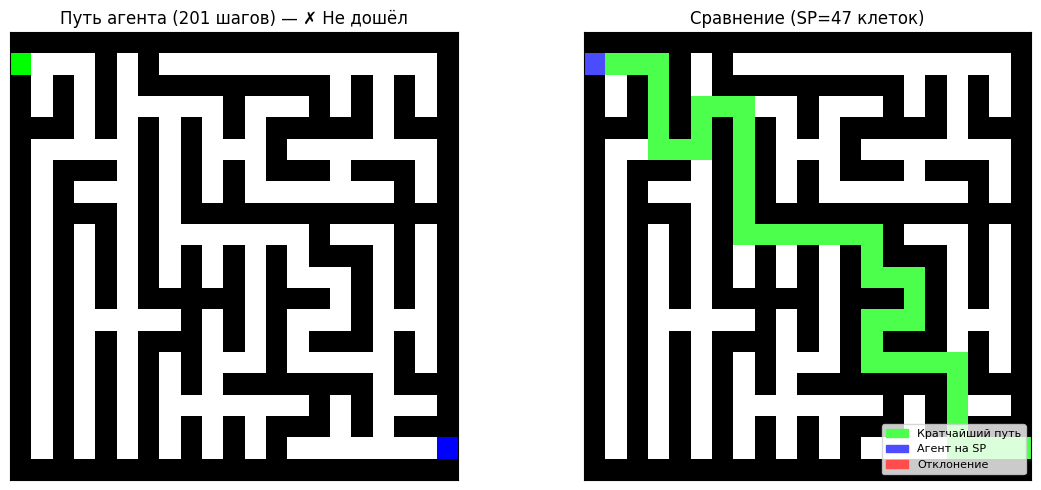


Лабиринт #23:


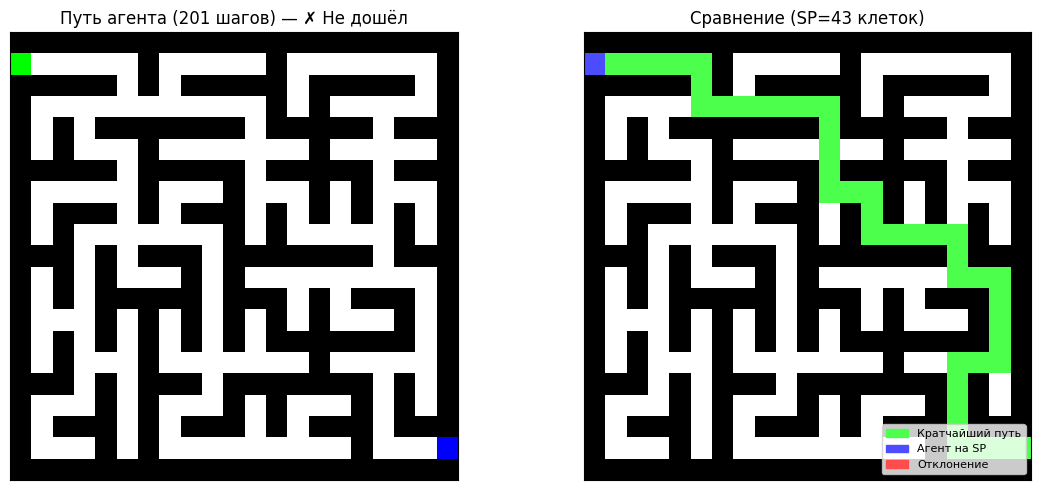


Лабиринт #51:


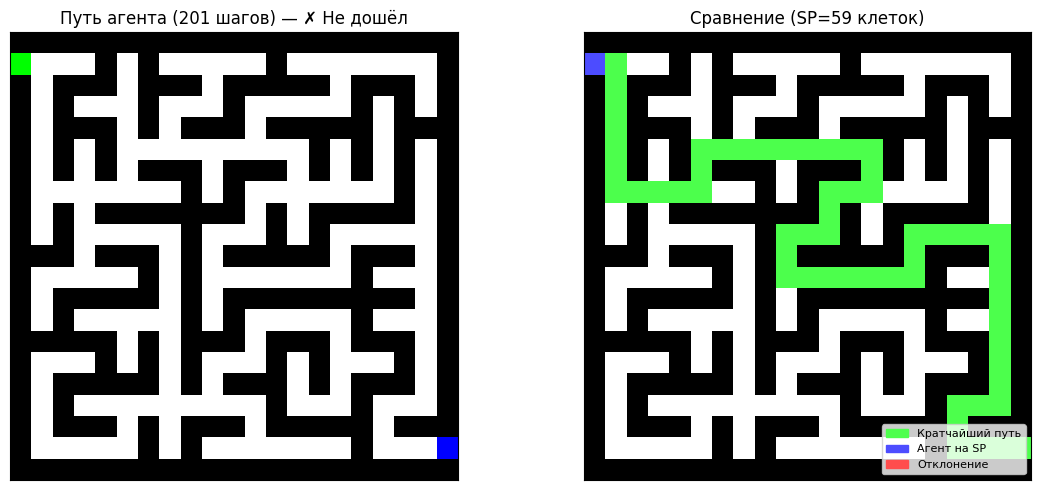

In [18]:
def visualize_solution(model, maze, sp_mask, max_steps=200):
    """Визуализация пути агента через лабиринт."""
    maze_f = maze.astype(np.float32)
    pos_r, pos_c = 1, 0
    path = [(pos_r, pos_c)]

    for _ in range(max_steps):
        if pos_r == 19 and pos_c == 20:
            break
        obs = np.zeros((1, 3, 21, 21), dtype=np.float32)
        obs[0, 0] = maze_f
        obs[0, 1, pos_r, pos_c] = 1.0
        obs[0, 2, 19, 20] = 1.0

        with torch.no_grad():
            logits, _ = model(torch.tensor(obs, device=device))
            action = logits.argmax(dim=-1).item()

        dr = [1, 0, -1, 0][action]
        dc = [0, 1, 0, -1][action]
        nr, nc = pos_r + dr, pos_c + dc
        if 0 <= nr < 21 and 0 <= nc < 21 and maze[nr, nc] == 1:
            pos_r, pos_c = nr, nc
        path.append((pos_r, pos_c))

    reached = (pos_r == 19 and pos_c == 20)

    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Путь агента
    img = np.stack([maze.astype(float)]*3, axis=-1)
    for r, c in path:
        img[r, c] = [1, 0.3, 0.3]  # красный
    img[1, 0] = [0, 1, 0]    # вход — зелёный
    img[19, 20] = [0, 0, 1]  # выход — синий
    axes[0].imshow(img)
    status = '✓ Выход найден!' if reached else '✗ Не дошёл'
    axes[0].set_title(f'Путь агента ({len(path)} шагов) — {status}')

    # Сравнение с кратчайшим путём
    img2 = np.stack([maze.astype(float)]*3, axis=-1)
    sp_cells = np.where(sp_mask > 0)
    for r, c in zip(sp_cells[0], sp_cells[1]):
        img2[r, c] = [0.3, 1, 0.3]  # зелёный — кратчайший путь
    for r, c in path:
        if sp_mask[r, c] < 0.5:
            img2[r, c] = [1, 0.3, 0.3]  # красный — отклонение
        else:
            img2[r, c] = [0.3, 0.3, 1]  # синий — совпадает
    axes[1].set_title(f'Сравнение (SP={int(sp_mask.sum())} клеток)')
    axes[1].imshow(img2)

    legend_elements = [
        mpatches.Patch(color=(0.3,1,0.3), label='Кратчайший путь'),
        mpatches.Patch(color=(0.3,0.3,1), label='Агент на SP'),
        mpatches.Patch(color=(1,0.3,0.3), label='Отклонение'),
    ]
    axes[1].legend(handles=legend_elements, loc='lower right', fontsize=8)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.show()


# Показать 5 примеров
for i in range(5):
    idx = np.random.randint(len(eval_mazes))
    print(f'\nЛабиринт #{idx}:')
    visualize_solution(model, eval_mazes[idx], sp_masks_eval[idx])

## 10. Сохранение модели

In [19]:
# Сохранить модель
torch.save(model.state_dict(), 'maze_solver_final.pt')
print('Модель сохранена в maze_solver_final.pt')

# Загрузить модель (при необходимости):
# model = MazeCNN().to(device)
# model.load_state_dict(torch.load('maze_solver_final.pt', map_location=device))
# model.eval()

Модель сохранена в maze_solver_final.pt
